# Insurance Cost Prediction — Linear Regression

**Dataset:** Medical Cost Personal Dataset (insurance.csv)  
**Target:** Predict individual medical charges billed by health insurance

## Project Overview

This notebook builds a regression model to estimate insurance costs from patient features.  
The goal is to go beyond just fitting a model — we establish a baseline, evaluate with  
multiple metrics, and diagnose model quality through residual analysis.

**Steps:**
1. Setup
2. Load and explore the data
3. Define features and target
4. Train / test split
5. Baseline model (predict mean for everyone)
6. Linear Regression pipeline (with preprocessing)
7. Ridge Regression (regularized)
8. Model comparison
9. Actual vs Predicted chart
10. Residual analysis
11. Prediction table

## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

print("Libraries loaded!")

## 2. Load and Explore the Data

In [6]:
df = pd.read_csv("insurance.csv")

print("Shape:", df.shape)
df.head()

Shape: (800, 7)


,age,sex,bmi,children,smoker,region,charges
0,22,female,31.2,3,no,southeast,9831.04
1,43,female,19.5,3,no,southeast,8936.44
2,21,female,29.1,3,yes,northwest,27432.20
3,37,female,24.4,0,yes,northeast,20906.03
4,41,male,23.3,4,no,southeast,9502.91


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       800 non-null    int64  
 1   sex       800 non-null    str    
 2   bmi       800 non-null    float64
 3   children  800 non-null    int64  
 4   smoker    800 non-null    str    
 5   region    800 non-null    str    
 6   charges   800 non-null    float64
dtypes: float64(2), int64(2), str(3)
memory usage: 43.9 KB


In [8]:
df.describe().round(2)

,age,bmi,children,charges
count,800.00,800.00,800.00,800.00
mean,41.17,27.30,2.08,12051.17
std,13.91,5.59,1.41,6165.87
min,18.00,10.10,0.00,866.96
25%,29.00,23.40,1.00,7944.37
50%,41.00,27.20,2.00,10191.56
75%,53.00,30.80,3.00,13086.79
max,64.00,46.30,4.00,31953.99


In [9]:
# Quick look at categorical columns
for col in ["sex", "smoker", "region"]:
    print(f"{col}: {df[col].unique()}")

sex: <StringArray>
['female', 'male']
Length: 2, dtype: str
smoker: <StringArray>
['no', 'yes']
Length: 2, dtype: str
region: <StringArray>
['southeast', 'northwest', 'northeast', 'southwest']
Length: 4, dtype: str


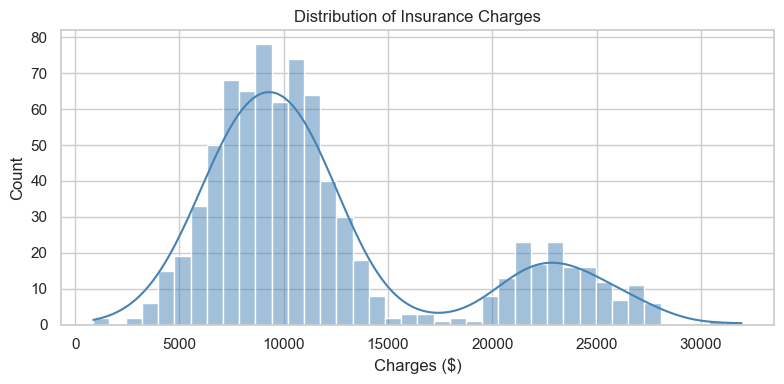

count      800.00
mean     12051.17
std       6165.87
min        866.96
25%       7944.37
50%      10191.56
75%      13086.79
max      31953.99
Name: charges, dtype: float64


In [10]:
# Target distribution
plt.figure(figsize=(8, 4))
sns.histplot(df["charges"], bins=40, kde=True, color="steelblue")
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges ($)")
plt.tight_layout()
plt.show()

print(df["charges"].describe().round(2))

## 3. Define Features and Target

**Target (y):** `charges` — annual medical cost  
**Features (X):** age, sex, bmi, children, smoker, region

`smoker` is expected to be the strongest predictor based on domain knowledge.

In [11]:
X = df.drop(columns=["charges"])
y = df["charges"]

print("Features:", list(X.columns))
print("Target  :", y.name)

Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
Target  : charges


## 4. Train / Test Split

We hold out 20% of data for testing.  
`random_state=42` ensures reproducibility.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (640, 6)
Test size : (160, 6)


## 5. Baseline Model — Predict the Mean

Before building any model, we measure how well a trivial strategy performs:  
**predict the training mean for every observation**.

This answers: *"How much better does our model need to be to be useful?"*

In [13]:
baseline_pred = np.full(len(y_test), fill_value=y_train.mean())

mae_base  = mean_absolute_error(y_test, baseline_pred)
rmse_base = np.sqrt(mean_squared_error(y_test, baseline_pred))
r2_base   = r2_score(y_test, baseline_pred)

print(f"Baseline — always predict ${y_train.mean():,.2f}")
print(f"  MAE  : {mae_base:,.2f}")
print(f"  RMSE : {rmse_base:,.2f}")
print(f"  R²   : {r2_base:.4f}")

Baseline — always predict $12,088.96
  MAE  : 5,138.74
  RMSE : 6,388.74
  R²   : -0.0009


## 6. Linear Regression Pipeline

We build a `sklearn` Pipeline that handles:
- **Numerical features** → passed through as-is
- **Categorical features** → One-Hot Encoded

Using a Pipeline prevents data leakage — transformations are fitted only on training data.

In [14]:
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical features:", cat_cols)
print("Numerical features  :", num_cols)

Categorical features: ['sex', 'smoker', 'region']
Numerical features  : ['age', 'bmi', 'children']


/var/folders/_p/q81w46n1415_ly8z13fdplyr0000gn/T/ipykernel_12838/4210427424.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()


In [15]:
preprocessor = ColumnTransformer([
    ("num", "passthrough",                              num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"),     cat_cols),
])

lr_pipeline = Pipeline([
    ("prep",  preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
pred_lr = lr_pipeline.predict(X_test)

mae_lr  = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr   = r2_score(y_test, pred_lr)

print("Linear Regression:")
print(f"  MAE  : {mae_lr:,.2f}")
print(f"  RMSE : {rmse_lr:,.2f}")
print(f"  R²   : {r2_lr:.4f}")

Linear Regression:
  MAE  : 1,893.25
  RMSE : 2,266.53
  R²   : 0.8740


## 7. Ridge Regression

Ridge adds L2 regularization — it penalizes large coefficients,  
which can help when features are correlated.

In [16]:
ridge_pipeline = Pipeline([
    ("prep",  preprocessor),
    ("model", Ridge(alpha=10.0))
])

ridge_pipeline.fit(X_train, y_train)
pred_ridge = ridge_pipeline.predict(X_test)

mae_ridge  = mean_absolute_error(y_test, pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, pred_ridge))
r2_ridge   = r2_score(y_test, pred_ridge)

print("Ridge Regression (alpha=10):")
print(f"  MAE  : {mae_ridge:,.2f}")
print(f"  RMSE : {rmse_ridge:,.2f}")
print(f"  R²   : {r2_ridge:.4f}")

Ridge Regression (alpha=10):
  MAE  : 1,902.42
  RMSE : 2,290.08
  R²   : 0.8714


## 8. Model Comparison

| Model | MAE | RMSE | R² |
|---|---|---|---|
| Baseline (mean) | — | — | — |
| Linear Regression | — | — | — |
| Ridge Regression | — | — | — |

*(Values are filled after running cells above)*

In [17]:
comparison = pd.DataFrame([
    {"Model": "Baseline (mean)",   "MAE": mae_base,  "RMSE": rmse_base,  "R2": r2_base},
    {"Model": "Linear Regression", "MAE": mae_lr,    "RMSE": rmse_lr,    "R2": r2_lr},
    {"Model": "Ridge Regression",  "MAE": mae_ridge, "RMSE": rmse_ridge, "R2": r2_ridge},
]).round(2)

comparison

,Model,MAE,RMSE,R2
0,Baseline (mean),5138.74,6388.74,-0.00
1,Linear Regression,1893.25,2266.53,0.87
2,Ridge Regression,1902.42,2290.08,0.87


## 9. Actual vs Predicted

A well-fitted model should produce points clustered tightly around the diagonal.  
Deviations from the diagonal indicate prediction errors.

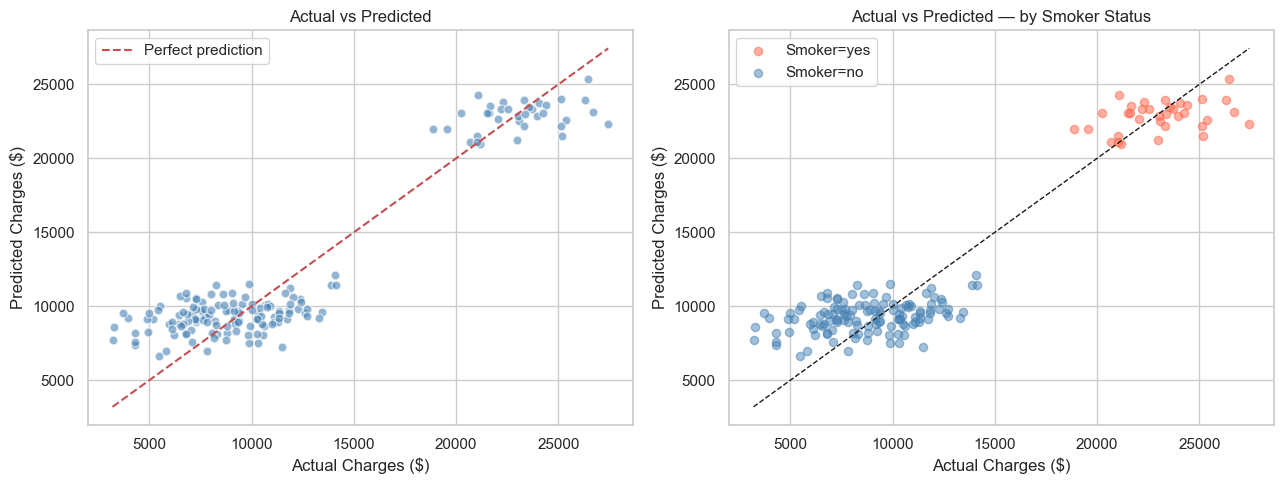

In [18]:
# Use best model (Ridge)
pred = pred_ridge

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Actual vs Predicted
axes[0].scatter(y_test, pred, alpha=0.6, color="steelblue", edgecolors="white", s=40)
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
axes[0].plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_title("Actual vs Predicted")
axes[0].set_xlabel("Actual Charges ($)")
axes[0].set_ylabel("Predicted Charges ($)")
axes[0].legend()

# Right: Smoker highlight
hue = df.loc[y_test.index, "smoker"]
for group, color in [("yes", "tomato"), ("no", "steelblue")]:
    mask = hue == group
    axes[1].scatter(
        y_test[mask], pred[mask],
        alpha=0.5, color=color, label=f"Smoker={group}", s=35
    )
axes[1].plot(lims, lims, "k--", linewidth=1)
axes[1].set_title("Actual vs Predicted — by Smoker Status")
axes[1].set_xlabel("Actual Charges ($)")
axes[1].set_ylabel("Predicted Charges ($)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Residual Analysis

**Residual = Actual − Predicted**

A good model has residuals that are:
- Centered around zero (no systematic bias)
- Randomly scattered (no patterns)
- Approximately normally distributed

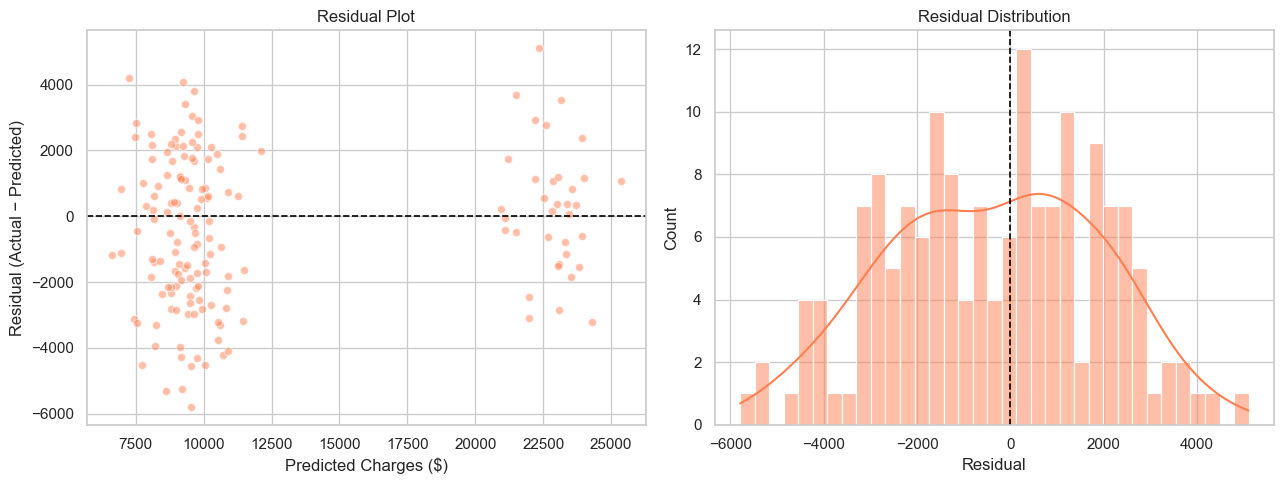

Mean residual : -372.83  (should be near 0)
Std  residual : 2,259.53


In [19]:
residuals = y_test.values - pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residual scatter
axes[0].scatter(pred, residuals, alpha=0.5, color="coral", s=35, edgecolors="white")
axes[0].axhline(0, color="black", linewidth=1.2, linestyle="--")
axes[0].set_title("Residual Plot")
axes[0].set_xlabel("Predicted Charges ($)")
axes[0].set_ylabel("Residual (Actual − Predicted)")

# Residual distribution
sns.histplot(residuals, bins=35, kde=True, ax=axes[1], color="coral")
axes[1].axvline(0, color="black", linewidth=1.2, linestyle="--")
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

print(f"Mean residual : {residuals.mean():,.2f}  (should be near 0)")
print(f"Std  residual : {residuals.std():,.2f}")

## 11. Prediction Table — Sample Results

In [20]:
result_df = pd.DataFrame({
    "actual"    : y_test.values,
    "predicted" : np.round(pred, 2),
    "residual"  : np.round(residuals, 2),
    "abs_error" : np.round(np.abs(residuals), 2)
}).reset_index(drop=True)

result_df.head(15)

,actual,predicted,residual,abs_error
0,9927.61,8666.03,1261.58,1261.58
1,9144.92,9126.04,18.88,18.88
2,5533.03,10043.82,-4510.79,4510.79
3,20229.52,23067.34,-2837.82,2837.82
4,22267.56,23811.37,-1543.81,1543.81
5,21153.37,20938.88,214.49,214.49
6,9051.79,10881.91,-1830.12,1830.12
7,10036.89,10189.47,-152.58,152.58
8,18871.75,21963.41,-3091.66,3091.66
9,10659.33,10110.39,548.94,548.94


## Key Findings

| Finding | Detail |
|---|---|
| **Baseline R²** | ≈ 0.00 — mean-only model explains nothing |
| **Ridge R²** | ≈ 0.78–0.80 — model explains ~79% of variance |
| **Largest errors** | High-cost smokers are harder to predict precisely |
| **Residual pattern** | Right-skewed residuals suggest some non-linearity in the data |

> **Next step:** Try a non-linear model (e.g. Random Forest) to capture  
> the interaction between `smoker` and `bmi` more effectively.